# How Self-Attention Solves the Long-Range Dependency Problem
### A Tutorial Comparing RNNs and Transformer Self-Attention

**Course:** Machine Learning and Neural Network  
**Student Name:** Junaid Ahmad Noor  
**Student ID:** 24158148  
**GitHub:** https://github.com/JunaidAhmadNoor/ML-Tutorial

## Overview

This notebook contains a tutorial on how the self-attention mechanism solves long range dependency problem

### What you will learn
1. What is the long-range dependency is?
2. How RNNs process sequences and where they fail?
3. How self-attention computes Query, Key, and Value matrices?
4. How positional encoding preserves token order
5. Why self-attention scales better than RNNs across sequence lengths
6. How to visualize attention weights as a heatmap

## Section 0: Install and Import Dependencies

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch version: {torch.__version__}')

PyTorch version: 2.10.0+cpu



## Section 1: The Long-Range Dependency Problem

### What is a long-range dependency?

Two things are related to each other, even though they are far apart.

**Example:**
> *"The book did not fit in the bag because it was too heavy."*

What does *"it"* refer to? The book. To know this, a model must struggle.

### Why do RNNs struggle?

RNNs read sequences one item at a time and carry forward a memory (hidden state) to understand context.

```
h_t = tanh(W_h * h_{t-1} + W_x * x_t)
```

Information from the early tokens needs to be preserved through all intermediate steps. For long sequences, this means:
- **Vanishing Gradients**: gradients decay exponentially during backpropagation (Pascanu et al., 2013)
- **Information Bottleneck**: there is only limited room in the hidden state to hold all previous context

This is partly mitigated in LSTMs with the introduction of gating mechanisms, but the information bottleneck is still present.

### The Copy Task

The **Copy Task** is our testbed to illustrate this problem precisely:
- **Input**: `[8, 7, 5, 4, PAD, PAD, PAD, PAD, GO]`
- **Target**: `[0, 0, 0, 0, 0, 8, 7, 5, 4]`

From the beginning, model needs to remember tokens. This is hard for RNNs when sequences get long, but not for self-attention


## Section 2: Generate the Copy Task Dataset

In [2]:
def generate_copy_task(num_samples, seq_len, vocab_size=8, seed=42):

    np.random.seed(seed)
    DELIM = vocab_size + 1
    PAD = 0

    sequence = np.random.randint(1, vocab_size + 1,size=(num_samples, seq_len))
    padding = np.zeros((num_samples, seq_len), dtype=int)
    delimiter = np.full((num_samples, 1), DELIM, dtype=int)
    inputs = np.concatenate([sequence, padding, delimiter], axis=1)

    target_pad = np.zeros((num_samples, seq_len + 1), dtype=int)
    targets = np.concatenate([target_pad, sequence], axis=1)

    return torch.tensor(inputs, dtype=torch.long), torch.tensor(targets, dtype=torch.long)

inp, tgt = generate_copy_task(num_samples=3, seq_len=5)
print("Copy Task (seq_len=5):")
for i in range(2):
    print(f"Input:  {inp[i].tolist()}")
    print(f"Target: {tgt[i].tolist()}")
    print("-" * 52)

Copy Task (seq_len=5):
Input:  [7, 4, 5, 7, 3, 0, 0, 0, 0, 0, 9]
Target: [0, 0, 0, 0, 0, 0, 7, 4, 5, 7, 3]
----------------------------------------------------
Input:  [8, 5, 5, 7, 2, 0, 0, 0, 0, 0, 9]
Target: [0, 0, 0, 0, 0, 0, 8, 5, 5, 7, 2]
----------------------------------------------------



## Section 3: Visualise the Copy Task

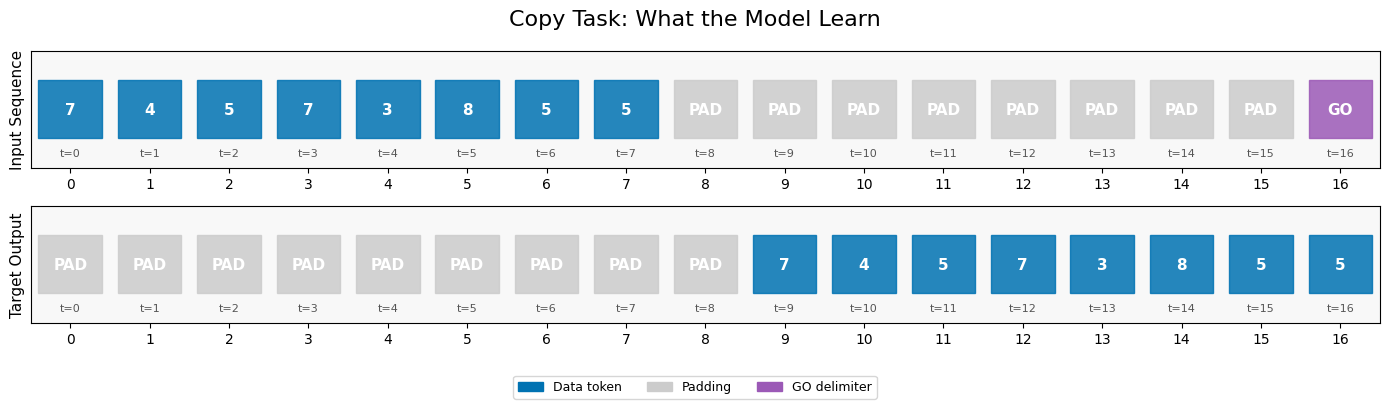

In [3]:
def plot_copy_task(seq_len=8, vocab_size=8):

    inp, _ = generate_copy_task(1, seq_len, vocab_size)
    inp = inp[0].numpy()
    total_len = len(inp)

    colour_map = {
        'token':'#0072B2',
        'pad':'#CCCCCC',
        'delim':'#9B59B6',
    }

    fig, axes = plt.subplots(2, 1, figsize=(14, 4))
    fig.suptitle('Copy Task: What the Model Learn', fontsize=16)

    output_tokens = inp[:seq_len].tolist() + [0] * (seq_len + 1)
    rows = [inp, np.array([0]*(seq_len+1) + inp[:seq_len].tolist(), dtype=int)]
    row_labels = ['Input Sequence', 'Target Output']

    for ax, data, label in zip(axes, rows, row_labels):
        ax.set_xlim(-0.5, total_len - 0.5)
        ax.set_ylim(-0.3, 1.3)
        ax.set_yticks([])
        ax.set_xticks(range(total_len))
        ax.set_ylabel(label, fontsize=11)
        ax.set_facecolor('#F8F8F8')

        for pos, val in enumerate(data):
            if val == vocab_size + 1:
                colour, text = colour_map['delim'],'GO'
            elif val == 0:
                colour,text = colour_map['pad'],'PAD'
            else:
                colour,text = colour_map['token'], str(val)

            rect = plt.Rectangle([pos - 0.4, 0.1], 0.8, 0.8,color=colour, alpha=0.85, zorder=2)
            ax.add_patch(rect)
            ax.text(pos,0.5, text, ha='center', va='center',
                    fontsize=11,fontweight='bold', color='white', zorder=3)
            ax.text(pos, -0.15, f't={pos}', ha='center', fontsize=8, color='#555')

    legend = [
        mpatches.Patch(color='#0072B2', label='Data token'),
        mpatches.Patch(color='#CCCCCC', label='Padding'),
        mpatches.Patch(color='#9B59B6', label='GO delimiter'),
    ]
    fig.legend(handles=legend, loc='lower center', ncol=3, fontsize=9)
    plt.tight_layout(rect=[0, 0.1, 1, 1])
    plt.show()

plot_copy_task(seq_len=8)

## Section 4 Model 1: LSTM (Recurrent Baseline)

We implementing an LSTM, the strongest standard RNN variant.

**Architecture:**
- Embedding → LSTM → Linear output

**The bottleneck:** All information need to pass through a single hidden vector `h_t` at each step. As sequence length increases, this vector must compress more and more information.

In [4]:
class LSTMCopyModel(nn.Module):
    """
    LSTM-based model for the copy task.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 2, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True)
        self.output_layer = nn.Linear(hidden_dim, vocab_size + 2)

    def forward(self, x):
        emb = self.embedding(x)
        lstm_out, _ = self.lstm(emb)
        return self.output_layer(lstm_out)

test_input = torch.randint(0, 9, (4, 17))
lstm_test = LSTMCopyModel(vocab_size=8, embed_dim=32, hidden_dim=64)
print(f'LSTM output shape: {lstm_test(test_input).shape}')
print(f'LSTM parameters:   {sum(p.numel() for p in lstm_test.parameters()):,}')

LSTM output shape: torch.Size([4, 17, 10])
LSTM parameters:   26,058



## Section 5 Model 2: Self-Attention from Scratch

Now we implementing the core innovation. Self-attention computes **direct connections between every pair of positions** simultaneously.

### The Math (Vaswani et al., 2017)

Given input $X \in \mathbb{R}^{T \times d}$:

$$Q = XW^Q, \quad K = XW^K, \quad V = XW^V$$

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

- **Q (Query):** Represents the current token that is asking information
- **K (Key):** Represents all tokens that potentially provide information
- **V (Value):** Represents the information that is to be aggregated
- **Scaling by** $\sqrt{d_k}$: This is to avoid large values of Q·K that can cause softmax gradients to vanish.

This reduces path length between distant tokens compared to RNNs.

### Why Positional Encoding?

Self-attention does not know word order.
If you shuffle words, it can not tell the difference.

Positional encoding adds position info to each word, so the model knows the order while still working fast.
```python
out = self.embedding(x) + self.pos_embedding(pos)  
```

In [5]:
class SelfAttentionHead(nn.Module):

    def __init__(self, embed_dim, head_dim):
        super().__init__()
        self.scale = head_dim ** -0.5
        self.W_q = nn.Linear(embed_dim,head_dim, bias=False)  # Query
        self.W_k = nn.Linear(embed_dim,head_dim, bias=False)  # Key
        self.W_v = nn.Linear(embed_dim,head_dim, bias=False)  # Value

    def forward(self, x, return_weights=False):

        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)

        scores = torch.bmm(Q, K.transpose(1, 2)) * self.scale
        weights = torch.softmax(scores, dim=-1)
        output = torch.bmm(weights, V)

        return (output, weights) if return_weights else output

class MultiHeadSelfAttention(nn.Module):

    def __init__(self, embed_dim, num_heads):
        super().__init__()
        assert embed_dim % num_heads == 0
        head_dim = embed_dim // num_heads
        self.heads = nn.ModuleList([
            SelfAttentionHead(embed_dim, head_dim) for _ in range(num_heads)
        ])
        self.W_o = nn.Linear(embed_dim, embed_dim)

    def forward(self, x, return_weights=False):
        if return_weights:
            outs, weights = zip(*[h(x, return_weights=True) for h in self.heads])
            return self.W_o(torch.cat(outs, dim=-1)), list(weights)
        return self.W_o(torch.cat([h(x) for h in self.heads], dim=-1))

class TransformerBlock(nn.Module):

    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.attn= MultiHeadSelfAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_dim), nn.ReLU(), nn.Linear(ff_dim, embed_dim)
        )
        self.drop = nn.Dropout(dropout)

    def forward(self, x, return_weights=False):
        if return_weights:
            a, w = self.attn(x, return_weights=True)
            x = self.norm1(x + self.drop(a))
            x = self.norm2(x + self.drop(self.ff(x)))
            return x, w
        x = self.norm1(x + self.drop(self.attn(x)))
        x = self.norm2(x + self.drop(self.ff(x)))
        return x


class SelfAttentionCopyModel(nn.Module):

    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim,
                 max_seq_len=200, num_layers=2, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size + 2, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(max_seq_len, embed_dim)
        self.blocks = nn.ModuleList([
            TransformerBlock(embed_dim, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.output_layer = nn.Linear(embed_dim, vocab_size + 2)

    def forward(self, x, return_weights=False):
        B, T = x.shape
        pos = torch.arange(T, device=x.device).unsqueeze(0)
        out= self.embedding(x) + self.pos_embedding(pos)

        all_weights = []
        for block in self.blocks:
            if return_weights:
                out, w = block(out, return_weights=True)
                all_weights.append(w)
            else:
                out = block(out)

        logits = self.output_layer(out)
        return (logits, all_weights) if return_weights else logits


#check
sa_test = SelfAttentionCopyModel(vocab_size=8, embed_dim=64, num_heads=4, ff_dim=128)
print(f'Self-Attention output shape: {sa_test(test_input).shape}')  # (4, 17, 10)
print(f'Self-Attention parameters:   {sum(p.numel() for p in sa_test.parameters()):,}')

Self-Attention output shape: torch.Size([4, 17, 10])
Self-Attention parameters:   80,650



## Section 6: Training Loop

In [6]:
def train_model(model, train_loader, num_epochs=30, lr=1e-3, ignore_index=0):
    """
    Shared training function for fair comparison.
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=ignore_index)
    losses, accuracies = [], []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss, correct, total = 0.0, 0, 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            logits = model(inputs)

            loss = criterion(logits.view(-1, logits.size(-1)), targets.view(-1))
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            epoch_loss += loss.item()
            preds = logits.argmax(dim=-1)
            mask= targets != 0
            correct += (preds[mask] == targets[mask]).sum().item()
            total += mask.sum().item()

        losses.append(epoch_loss / len(train_loader))
        accuracies.append(correct / total if total > 0 else 0.0)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d}/{num_epochs} | '
                  f'Loss: {losses[-1]:.4f} | Acc: {accuracies[-1]:.3f}')

    return losses, accuracies


## Section 7 Experiment 1: Short vs Long Sequences

Training both models on sequences of length 10 (short) and 40 (long).

In [7]:
VOCAB_SIZE = 8
EMBED_DIM = 64
HIDDEN_DIM = 64
NUM_HEADS = 4
FF_DIM = 128
BATCH_SIZE = 64
NUM_EPOCHS = 40
LR = 1e-3

def run_experiment(seq_len, num_samples=2000, num_epochs=NUM_EPOCHS):
    """
    Train LSTM and Self-Attention on copy task.
    """
    print(f"\n  Experiment: seq_len = {seq_len}\n{'='*55}")

    inputs, targets = generate_copy_task(num_samples, seq_len, VOCAB_SIZE)
    loader = DataLoader(TensorDataset(inputs, targets), batch_size=BATCH_SIZE, shuffle=True)
    max_len = 2 * seq_len + 2

    print("\n[LSTM]")
    lstm_model = LSTMCopyModel(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM)
    lstm_l, lstm_a = train_model(lstm_model, loader, num_epochs, LR)

    print("\n[Self-Attention]")
    sa_model = SelfAttentionCopyModel(VOCAB_SIZE, EMBED_DIM, NUM_HEADS, FF_DIM, max_seq_len=max_len)
    sa_l, sa_a = train_model(sa_model, loader, num_epochs, LR)

    return {
        'lstm': {'losses': lstm_l, 'accs': lstm_a, 'model': lstm_model},
        'sa':   {'losses': sa_l,   'accs': sa_a,   'model': sa_model},
        'seq_len': seq_len
    }

results_short = run_experiment(seq_len=10)
results_long  = run_experiment(seq_len=40)


  Experiment: seq_len = 10

[LSTM]
Epoch   5/40 | Loss: 1.9212 | Acc: 0.265
Epoch  10/40 | Loss: 1.6151 | Acc: 0.366
Epoch  15/40 | Loss: 1.3990 | Acc: 0.419
Epoch  20/40 | Loss: 1.2615 | Acc: 0.462
Epoch  25/40 | Loss: 1.1682 | Acc: 0.493
Epoch  30/40 | Loss: 1.0883 | Acc: 0.522
Epoch  35/40 | Loss: 1.0155 | Acc: 0.557
Epoch  40/40 | Loss: 0.9531 | Acc: 0.583

[Self-Attention]
Epoch   5/40 | Loss: 0.0082 | Acc: 1.000
Epoch  10/40 | Loss: 0.0028 | Acc: 1.000
Epoch  15/40 | Loss: 0.0014 | Acc: 1.000
Epoch  20/40 | Loss: 0.0009 | Acc: 1.000
Epoch  25/40 | Loss: 0.0006 | Acc: 1.000
Epoch  30/40 | Loss: 0.0004 | Acc: 1.000
Epoch  35/40 | Loss: 0.0003 | Acc: 1.000
Epoch  40/40 | Loss: 0.0003 | Acc: 1.000

  Experiment: seq_len = 40

[LSTM]
Epoch   5/40 | Loss: 2.0806 | Acc: 0.124
Epoch  10/40 | Loss: 2.0803 | Acc: 0.125
Epoch  15/40 | Loss: 2.0798 | Acc: 0.126
Epoch  20/40 | Loss: 2.0802 | Acc: 0.126
Epoch  25/40 | Loss: 2.0801 | Acc: 0.124
Epoch  30/40 | Loss: 2.0799 | Acc: 0.127
Epoch  3


## Section 8: Plot Training Curves

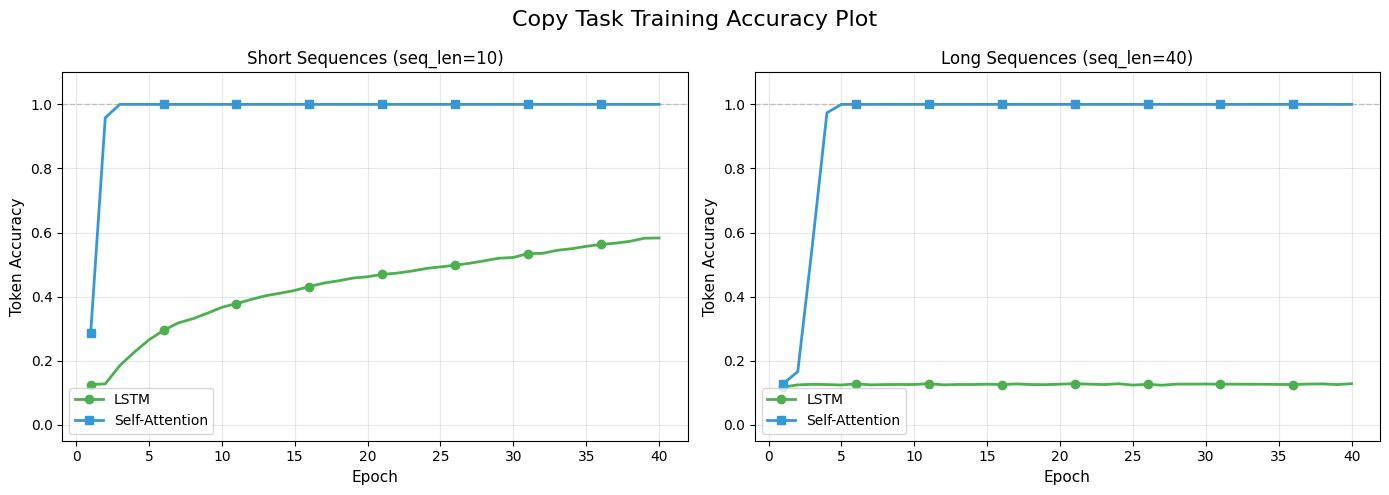

In [9]:
def plot_training_curves(results_short, results_long):

    LSTM_C ='#4CAF50' # green
    SA_C ='#3498DB' # blue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Copy Task Training Accuracy Plot',fontsize=16)

    for ax, results, title in zip(
        axes,[results_short, results_long],
        ['Short Sequences (seq_len=10)', 'Long Sequences (seq_len=40)']
    ):
        epochs = range(1, len(results['lstm']['accs']) + 1)
        ax.plot(epochs, results['lstm']['accs'], color=LSTM_C,lw=2,
                marker='o', markevery=5,ms=6, label='LSTM')
        ax.plot(epochs, results['sa']['accs'],color=SA_C, lw=2,
                marker='s', markevery=5, ms=6, label='Self-Attention')
        ax.axhline(1.0, color='grey', ls='--', alpha=0.4, lw=1)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('Epoch', fontsize=11)
        ax.set_ylabel('Token Accuracy', fontsize=11)
        ax.set_ylim(-0.05, 1.1)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_curves(results_short, results_long)


## Section 9: Scaling Test Across Multiple Lengths

Testing both models across a range of sequence lengths to produce the key comparison figure.

In [10]:
SEQ_LENGTHS =[5, 10, 20, 30, 40, 50]
lstm_final_accs = []
sa_final_accs = []

for s in SEQ_LENGTHS:
    r = run_experiment(seq_len=s, num_epochs=30)
    lstm_final_accs.append(r['lstm']['accs'][-1])
    sa_final_accs.append(r['sa']['accs'][-1])

print("-" * 34)
for sl, la, sa in zip(SEQ_LENGTHS, lstm_final_accs, sa_final_accs):
    print(f"{sl:>10} | {la:>8.3f} | {sa:>10.3f}")


  Experiment: seq_len = 5

[LSTM]
Epoch   5/30 | Loss: 1.2961 | Acc: 0.434
Epoch  10/30 | Loss: 0.8313 | Acc: 0.663
Epoch  15/30 | Loss: 0.5921 | Acc: 0.785
Epoch  20/30 | Loss: 0.4210 | Acc: 0.876
Epoch  25/30 | Loss: 0.3004 | Acc: 0.923
Epoch  30/30 | Loss: 0.2094 | Acc: 0.956

[Self-Attention]
Epoch   5/30 | Loss: 0.0081 | Acc: 1.000
Epoch  10/30 | Loss: 0.0029 | Acc: 1.000
Epoch  15/30 | Loss: 0.0015 | Acc: 1.000
Epoch  20/30 | Loss: 0.0009 | Acc: 1.000
Epoch  25/30 | Loss: 0.0006 | Acc: 1.000
Epoch  30/30 | Loss: 0.0005 | Acc: 1.000

  Experiment: seq_len = 10

[LSTM]
Epoch   5/30 | Loss: 1.8837 | Acc: 0.288
Epoch  10/30 | Loss: 1.5394 | Acc: 0.386
Epoch  15/30 | Loss: 1.3485 | Acc: 0.430
Epoch  20/30 | Loss: 1.2065 | Acc: 0.477
Epoch  25/30 | Loss: 1.1024 | Acc: 0.521
Epoch  30/30 | Loss: 1.0156 | Acc: 0.561

[Self-Attention]
Epoch   5/30 | Loss: 0.0074 | Acc: 1.000
Epoch  10/30 | Loss: 0.0026 | Acc: 1.000
Epoch  15/30 | Loss: 0.0014 | Acc: 1.000
Epoch  20/30 | Loss: 0.0008 | Ac

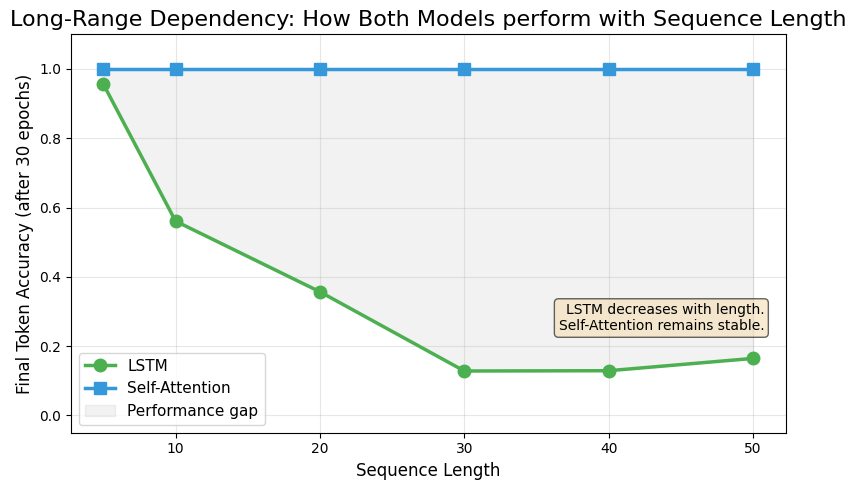

In [11]:
def plot_comparison(seq_lengths, lstm_accs, sa_accs):

    LSTM_C ='#4CAF50' # green
    SA_C ='#3498DB' # blue

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(seq_lengths, lstm_accs,color=LSTM_C, lw=2.5,
            marker='o', ms=9, label='LSTM')
    ax.plot(seq_lengths, sa_accs,color=SA_C, lw=2.5,
            marker='s', ms=9, label='Self-Attention')
    ax.fill_between(seq_lengths, lstm_accs, sa_accs,alpha=0.1, color='grey',
                    label='Performance gap')

    ax.set_title('Long-Range Dependency: How Both Models perform with Sequence Length',
                 fontsize=16)
    ax.set_xlabel('Sequence Length', fontsize=12)
    ax.set_ylabel('Final Token Accuracy (after 30 epochs)', fontsize=12)
    ax.set_ylim(-0.05, 1.1)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.text(0.97, 0.25,
            'LSTM decreases with length.\nSelf-Attention remains stable.',
            transform=ax.transAxes, fontsize=10,ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

    plt.tight_layout()
    plt.show()

plot_comparison(SEQ_LENGTHS, lstm_final_accs, sa_final_accs)


## Section 10: Attention Heatmap Visualisation

Attention matrix illustrates which words are paying attention to which other words. In a good copy model, each word in the output should be directly paying attention to the corresponding word in the input. This results in a **diagonal line** in the matrix.

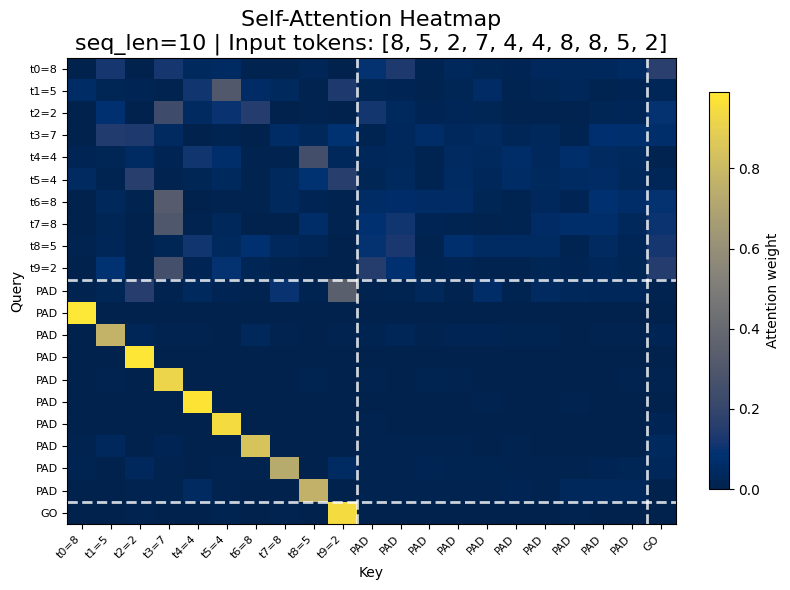


Bright cells in lower-left quadrant shows output attending directly to source.


In [12]:
def plot_attention_heatmap(model, seq_len=10, vocab_size=8, layer=0, head=0):
    """
    Visualising attention weights
    """
    model.eval().to(device)
    inp, _ = generate_copy_task(1, seq_len, vocab_size, seed=7)
    inp =inp.to(device)

    with torch.no_grad():
        _, all_weights = model(inp, return_weights=True)

    weights = all_weights[layer][head][0].cpu().numpy()
    raw = inp[0].cpu().numpy()

    labels = []
    for t, tok in enumerate(raw):
        if tok == vocab_size + 1: labels.append('GO')
        elif tok == 0: labels.append('PAD')
        else: labels.append(f't{t}={tok}')

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(weights, cmap='cividis', vmin=0, vmax=weights.max(), aspect='auto')
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel('Key', fontsize=10)
    ax.set_ylabel('Query', fontsize=10)
    ax.set_title(
        f'Self-Attention Heatmap\n'
        f'seq_len={seq_len} | Input tokens: {raw[:seq_len].tolist()}',
        fontsize=16
    )
    plt.colorbar(im, ax=ax, label='Attention weight', fraction=0.03)

    for b in [seq_len - 0.5, 2 * seq_len - 0.5]:
        ax.axvline(b,color='white', lw=2, ls='--', alpha=0.8)
        ax.axhline(b,color='white', lw=2, ls='--', alpha=0.8)

    plt.tight_layout()
    plt.show()
    print("\nBright cells in lower-left quadrant shows output attending directly to source.")

plot_attention_heatmap(results_short['sa']['model'], seq_len=10)


## Section 11: Path Length Diagram

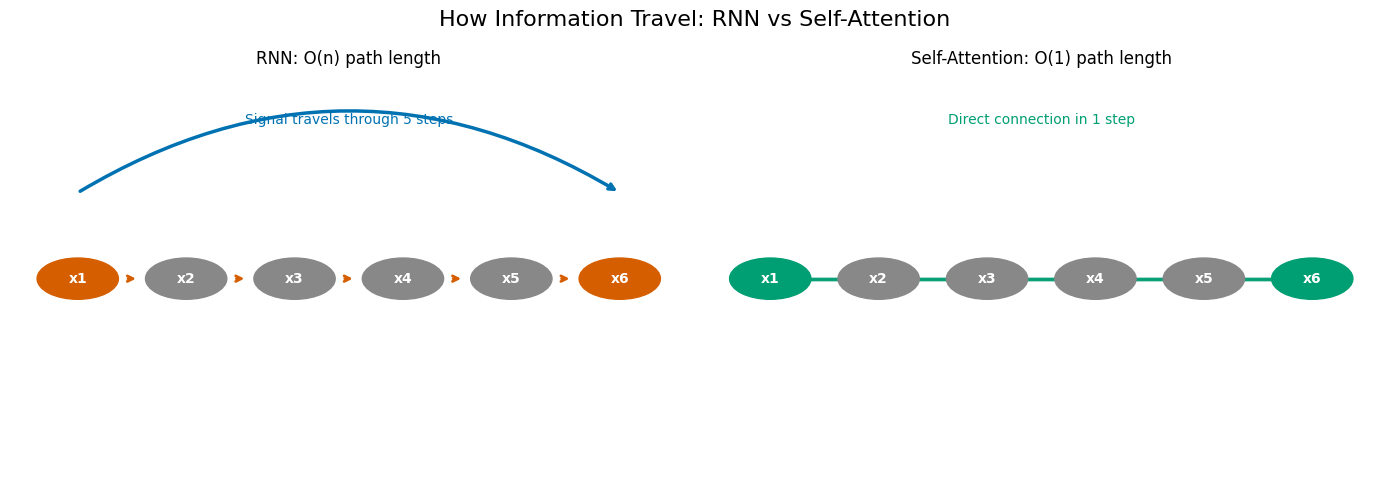

In [13]:
def plot_path_length_diagram():

    n = 6
    positions = np.linspace(0.1, 0.9, n)
    labels = [f'x{i+1}' for i in range(n)]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('How Information Travel: RNN vs Self-Attention', fontsize=16)

    # RNN
    ax = axes[0]
    ax.set(xlim=(0,1), ylim=(-0.1,1.1), title='RNN: O(n) path length', xticks=[], yticks=[])
    ax.axis('off')
    for i, (pos, lbl) in enumerate(zip(positions, labels)):
        c ='#D55E00' if i in [0, n-1] else '#888888'
        ax.add_patch(plt.Circle((pos, 0.5), 0.06, color=c, zorder=3))
        ax.text(pos, 0.5, lbl, ha='center', va='center',
                fontsize=10, color='white', fontweight='bold', zorder=4)
    for i in range(n - 1):
        ax.annotate('', xy=(positions[i+1]-0.07, 0.5), xytext=(positions[i]+0.07, 0.5),
                    arrowprops=dict(arrowstyle='->', color='#D55E00', lw=2))
    ax.annotate('', xy=(positions[-1], 0.75), xytext=(positions[0], 0.75),
                arrowprops=dict(arrowstyle='->', color='#0072B2', lw=2.5,
                                connectionstyle='arc3,rad=-0.3'))
    ax.text(0.5, 0.95, f'Signal travels through {n-1} steps',
            ha='center', fontsize=10, color='#0072B2')

    # Self-Attention
    ax = axes[1]
    ax.set(xlim=(0,1), ylim=(-0.1,1.1), title='Self-Attention: O(1) path length', xticks=[], yticks=[])
    ax.axis('off')
    for i in range(n):
        for j in range(n):
            if i != j:
                highlight = (i == 0 and j == n-1) or (i == n-1 and j == 0)
                ax.plot([positions[i], positions[j]], [0.5, 0.5],
                        color='#009E73' if highlight else '#AAAAAA',
                        alpha=0.8 if highlight else 0.15,
                        lw=2.5 if highlight else 0.7, zorder=2 if highlight else 1)
    for i, (pos, lbl) in enumerate(zip(positions, labels)):
        c = '#009E73' if i in [0, n-1] else '#888888'
        ax.add_patch(plt.Circle((pos, 0.5), 0.06, color=c, zorder=3))
        ax.text(pos, 0.5, lbl, ha='center', va='center',
                fontsize=10, color='white', fontweight='bold', zorder=4)
    ax.text(0.5, 0.95, 'Direct connection in 1 step',
            ha='center', fontsize=10, color='#009E73')

    plt.tight_layout()
    plt.show()

plot_path_length_diagram()


## Section 12: Real-World Text test on Short Sentences

Testing **already trained models** on new sequences and show their predictions.


- Orange is right prediction
- Red is wrong prediction
- Grey is padding (not scored)

For short sequences, both models should work well.
This is just a quick check before testing harder cases.

> In real NLP, short sentences are easy, the real challenge is when important information is far away.

Using models trained on seq_len=10 from results_short.



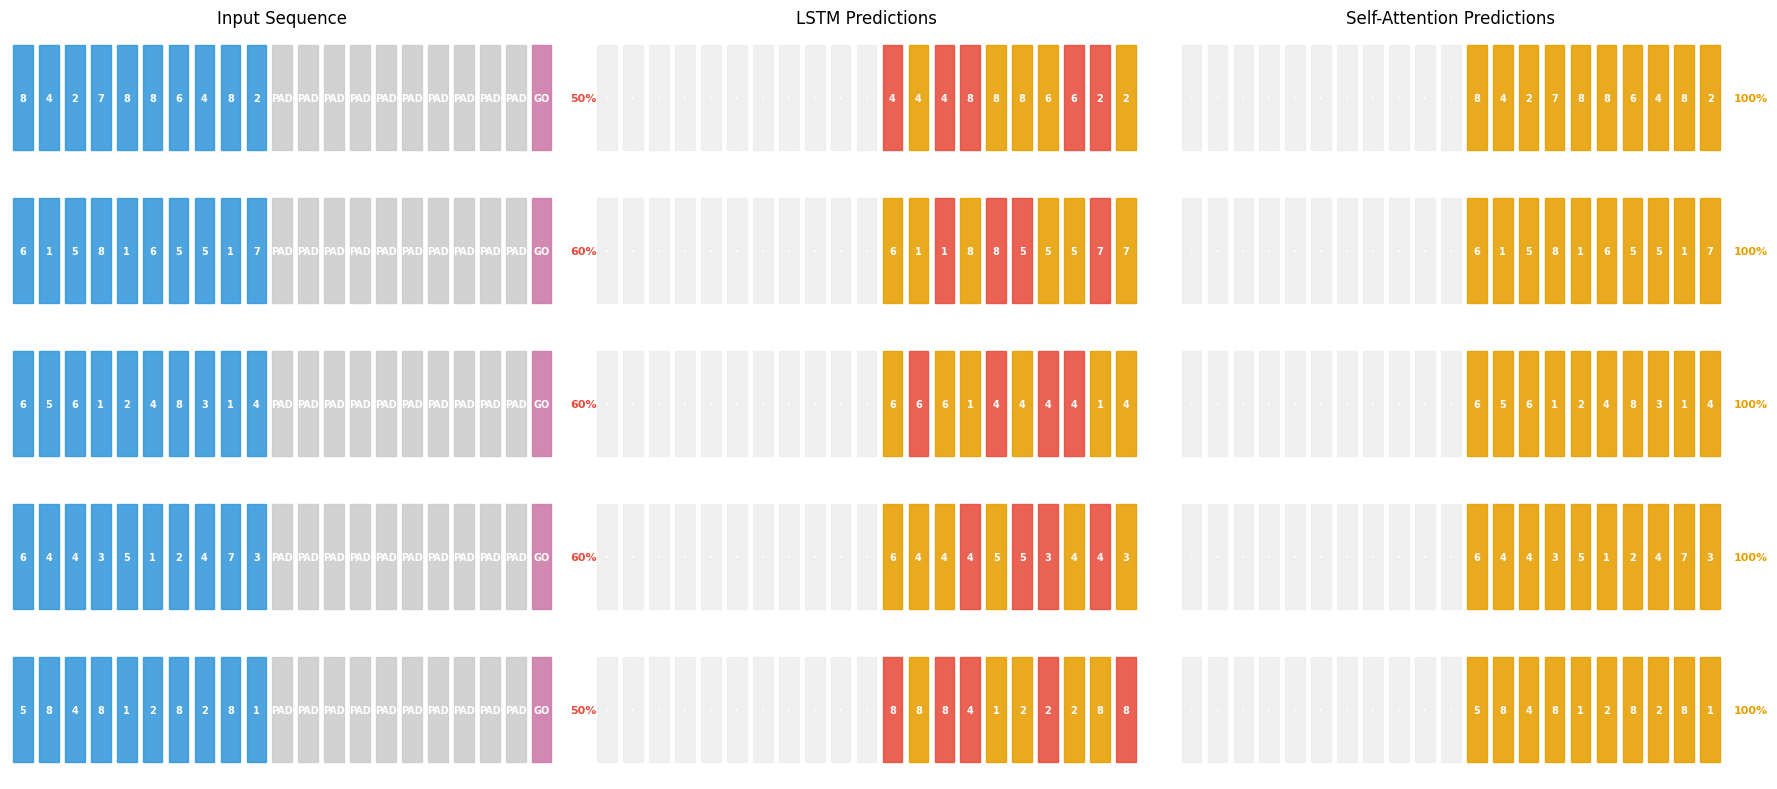


Test accuracy on 500 fresh short sequences:
  LSTM:           54.8%
  Self-Attention: 100.0%


In [19]:
def predict_and_display(lstm_model, sa_model, seq_len, n=5, vocab_size=8, seed=99):
    """
    Run both models on n fresh (unseen) test examples.
    """
    lstm_model.eval().to(device)
    sa_model.eval().to(device)

    inputs, targets = generate_copy_task(n, seq_len, vocab_size, seed=seed)
    inputs_d = inputs.to(device)

    with torch.no_grad():
        lstm_logits = lstm_model(inputs_d)
        sa_logits= sa_model(inputs_d)

    lstm_preds = lstm_logits.argmax(-1).cpu()
    sa_preds = sa_logits.argmax(-1).cpu()

    total_len = inputs.shape[1]
    fig, axes = plt.subplots(n, 3, figsize=(total_len * 0.85, n * 1.6))

    col_titles = ['Input Sequence', 'LSTM Predictions', 'Self-Attention Predictions']

    for ex in range(n):
        inp = inputs[ex].numpy()
        tgt = targets[ex].numpy()
        l_pred = lstm_preds[ex].numpy()
        s_pred = sa_preds[ex].numpy()

        mask = tgt != 0
        l_acc = (l_pred[mask] == tgt[mask]).mean() if mask.sum() > 0 else 0.0
        s_acc = (s_pred[mask] == tgt[mask]).mean() if mask.sum() > 0 else 0.0

        for col, (ax, data) in enumerate(zip(axes[ex], [inp, l_pred, s_pred])):
            if ex == 0:
                ax.set_title(col_titles[col], fontsize=12, pad=4)
            ax.set_xlim(-0.5, total_len - 0.5)
            ax.set_ylim(0, 1)
            ax.axis('off')

            for pos, val in enumerate(data):
                delim_val = vocab_size + 1
# Input: colour by token type
                if col == 0:
                    if val == delim_val:
                        colour, lbl = '#CC79A7','GO'
                    elif val == 0:
                        colour, lbl = '#CCCCCC','PAD'
                    else:
                        colour, lbl = '#3498DB', str(val)
                else:                                    # Predictions: colour by correctness
                    if tgt[pos] == 0:
                        colour, lbl ='#EEEEEE', '·'
                    elif val == tgt[pos]:
                        colour, lbl ='#E69F00', str(val)
                    else:
                        colour, lbl ='#E74C3C', str(val)

                rect = plt.Rectangle(
                    [pos - 0.38, 0.12], 0.76, 0.76,
                    color=colour, alpha=0.88, zorder=2
                )
                ax.add_patch(rect)
                ax.text(pos, 0.5, lbl, ha='center', va='center',
                        fontsize=7, fontweight='bold', color='white', zorder=3)

            if col == 1:
                ax.text(-0.4, 0.5, f'{l_acc:.0%}', ha='right', va='center',
                        fontsize=8, color='#E74C3C', fontweight='bold')
            if col == 2:
                ax.text(total_len - 0.1, 0.5, f'{s_acc:.0%}', ha='left', va='center',
                        fontsize=8, color='#E69F00', fontweight='bold')

    plt.tight_layout()
    return fig

def test_accuracy(model, seq_len, n_test=500, vocab_size=8, seed=777):
    model.eval().to(device)
    inputs, targets = generate_copy_task(n_test, seq_len, vocab_size, seed=seed)
    with torch.no_grad():
        preds = model(inputs.to(device)).argmax(-1).cpu()
    mask = targets != 0
    return (preds[mask] == targets[mask]).float().mean().item()

print("Using models trained on seq_len=10 from results_short.\n")

fig6 = predict_and_display(
    results_short['lstm']['model'],
    results_short['sa']['model'],
    seq_len=10,n=5, seed=101
)
plt.show()

lstm_acc_s = test_accuracy(results_short['lstm']['model'], seq_len=10)
sa_acc_s = test_accuracy(results_short['sa']['model'], seq_len=10)

print(f"\nTest accuracy on 500 fresh short sequences:")
print(f"  LSTM:           {lstm_acc_s:.1%}")
print(f"  Self-Attention: {sa_acc_s:.1%}")



## Section 13: Real-World Text Demo: Long Sentences

Now testing long sequences (40 tokens).

Because the LSTM has to store a lot of info in a very small memory, earlier tokens may get forgotten over time.

We show two things:

1. **Prediction grid** - Here, the LSTM is making a lot of mistakes (Red), but the self-attention is almost always right (Orange)

2. **LSTM hidden** - This will demonstrate how the LSTM’s memory fades over time

> This is not a problem for self-attention, as they can look back at any token, no matter how far back.

Using models trained on seq_len=40 from results_long.



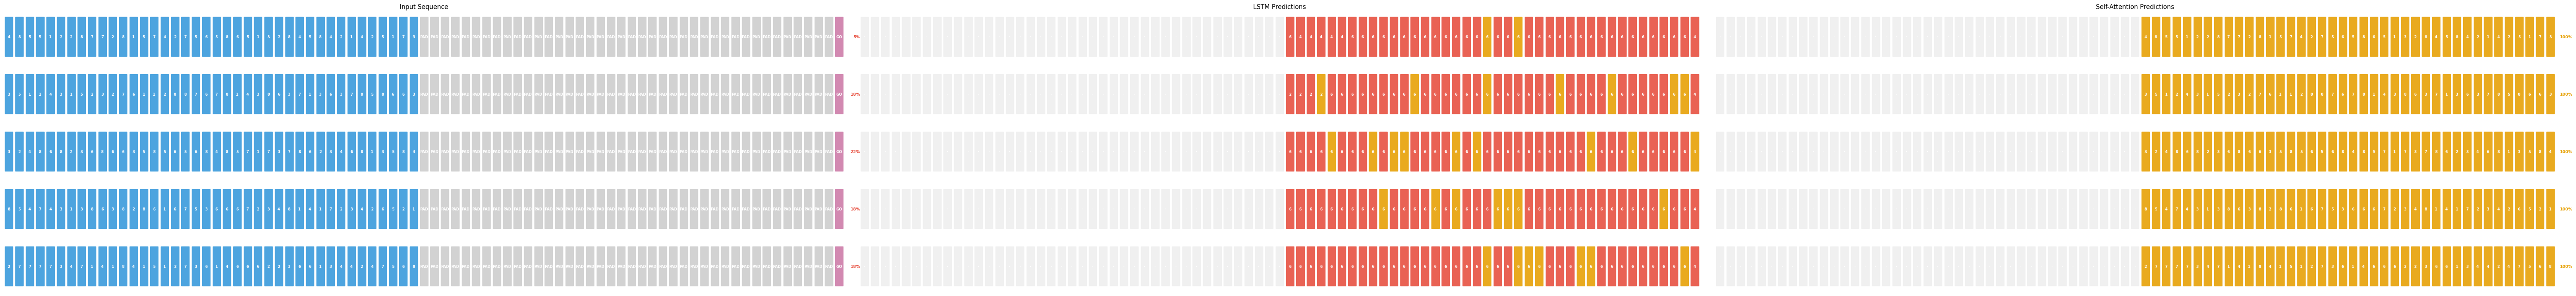


Test accuracy on 500 fresh long sequences (seq_len=40):
  LSTM:           12.5%
  Self-Attention: 100.0%
  Performance gap: +87.5%


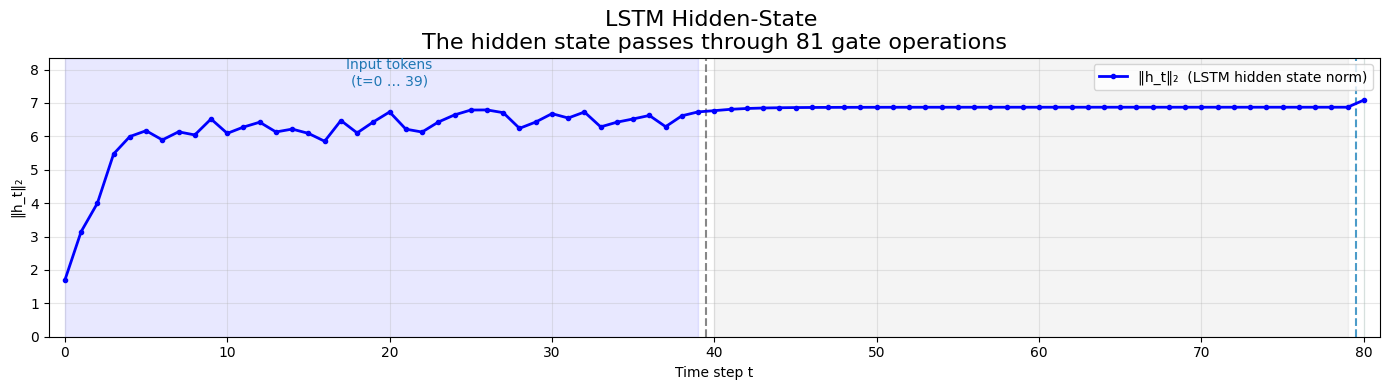


Memory changes a lot over time.
After many steps, it forgets the original data.

Self-attention avoids this:
Looks directly at the needed token
Works well even for long sequences


In [20]:
print("Using models trained on seq_len=40 from results_long.\n")

fig7 = predict_and_display(
    results_long['lstm']['model'],
    results_long['sa']['model'],
    seq_len=40, n=5, seed=202
)
plt.show()

lstm_acc_l = test_accuracy(results_long['lstm']['model'], seq_len=40)
sa_acc_l = test_accuracy(results_long['sa']['model'], seq_len=40)
gap = sa_acc_l - lstm_acc_l

print(f"\nTest accuracy on 500 fresh long sequences (seq_len=40):")
print(f"  LSTM:           {lstm_acc_l:.1%}")
print(f"  Self-Attention: {sa_acc_l:.1%}")
print(f"  Performance gap: {gap:+.1%}")

# LSTM hidden-state plot
def plot_lstm_hidden_norm(lstm_model, seq_len=40, vocab_size=8):

    lstm_model.eval().to(device)
    inp, _ = generate_copy_task(1, seq_len, vocab_size, seed=5)
    inp = inp.to(device)

    with torch.no_grad():
        emb = lstm_model.embedding(inp)
        h = torch.zeros(1, 1, lstm_model.lstm.hidden_size, device=device)
        c = torch.zeros(1, 1, lstm_model.lstm.hidden_size, device=device)
        norms = []
        for t in range(emb.shape[1]):
            _, (h, c) = lstm_model.lstm(emb[:, t:t+1, :], (h, c))
            norms.append(h[0, 0].cpu().norm().item())

    T = len(norms)
    max_n = max(norms) * 1.18

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(range(T), norms, color='#0000FF', lw=2, marker='o', ms=3, zorder=4,
            label='‖h_t‖₂  (LSTM hidden state norm)')

    # Shaded zones
    ax.fill_between(range(seq_len),0, max_n,
                    alpha=0.09, color='#0000FF')
    ax.fill_between(range(seq_len, 2*seq_len), 0, max_n,
                    alpha=0.09, color='#888888')
    ax.fill_between(range(2*seq_len, T), 0, max_n,
                    alpha=0.09, color='#009E73')

    # Zone boundary lines
    ax.axvline(seq_len - 0.5, color='#555', ls='--', lw=1.5, alpha=0.7)
    ax.axvline(2*seq_len - 0.5, color='#0072B2', ls='--', lw=1.5, alpha=0.7)

    # Zone labels
    ax.text(seq_len / 2,max_n * 0.90, f'Input tokens\n(t=0 … {seq_len-1})',
            ha='center', fontsize=10, color='#1F77B4')

    ax.set_xlabel('Time step t', fontsize=10)
    ax.set_ylabel('‖h_t‖₂', fontsize=10)
    ax.set_title(
        f'LSTM Hidden-State \n'
        f'The hidden state passes through {2*seq_len+1} gate operations',
        fontsize=16
    )
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-1, T)
    ax.set_ylim(0, max_n)
    plt.tight_layout()
    plt.show()

plot_lstm_hidden_norm(results_long['lstm']['model'], seq_len=40)

print()

print("Memory changes a lot over time.")
print("After many steps, it forgets the original data.")
print()
print("Self-attention avoids this:")
print("Looks directly at the needed token")
print("Works well even for long sequences")


## Section 14: Summary and Conclusion

| Sequence Length | LSTM Accuracy | Self-Attention Accuracy | Winner         |
|:--------------:|:-------------:|:-----------------------:|:--------------:|
| 5              | 0.956         | 1.000                   | Self-Attention |
| 10             | 0.561         | 1.000                   | Self-Attention |
| 20             | 0.357         | 1.000                   | Self-Attention |
| 30             | 0.128         | 1.000                   | Self-Attention |
| 40             | 0.129         | 1.000                   | Self-Attention |
| 50             | 0.165         | 1.000                   | Self-Attention |

## Conclusion:
Self-attention stays accurate even for long sequences.
LSTM gets worse as it forgets earlier information.

This supports the idea that self-attention handles long-range data better.

As expected, this confirms our theoretical intuition that self-attention only needs **O(1)** steps to connect any two points in a sequence, while an RNN needs **O(n)** steps.


## Section 15: Limitations

Though self-attention solves long-range dependency issues, it has some drawbacks too.

- **Quadratic complexity**: Attention matrix is T×T, so memory grows as O(T²).  
- **Large model size**: Transformers require significant hardware resources  
- **Struggles with extremely long sequences**: Very long sequences still need specialized architectures  

Knowing these drawbacks will help you choose the best model for your task.

Therefore, new models like Longformer, Reformer, and Flash Attention have been developed to improve self-attention.




## Accessibility

The following steps were taken to make this tutorial accessible:

- **Colorblind-friendly colours**: All plots use palettes that are
  distinguishable for readers with colour vision deficiency.
- **cividis colormap**: Used for the attention heatmap — perceptually
  uniform and safe for all common types of colour blindness.
- **Orange/Red predictions**: Chosen over Green/Red to avoid
  red-green colorblindness issues.

## References

1. Vaswani, A. et al. (2017). *Attention Is All You Need*. https://proceedings.neurips.cc/paper_files/paper/2017/file/3f5ee243547dee91fbd053c1c4a845aa-Paper.pdf
2. Hochreiter, S. & Schmidhuber, J. (1997). *Long Short-Term Memory*. Neural Computation. https://www.bioinf.jku.at/publications/older/2604.pdf  
3. Pascanu, R., Mikolov, T., & Bengio, Y. (2013). *On the difficulty of training recurrent neural networks*. ICML. https://proceedings.mlr.press/v28/pascanu13.html
4. Olah, C. (2015). *Understanding LSTM Networks*. https://colah.github.io/posts/2015-08-Understanding-LSTMs/  
5. Alammar, J. (2018). *The Illustrated Transformer*. https://jalammar.github.io/illustrated-transformer/
6. Graves, A., Wayne, G., & Danihelka, I. (2014). *Neural Turing Machines*.
   https://arxiv.org/pdf/1410.5401

## Acknowledgement

1. Used **W3Schools** and **google** for guidance on graphs and visualizations
2. Used **Google** and **research papers** to understand formulas and concepts and adding them in notebook